In [1]:
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import joblib


In [2]:
# 2. LOAD DATA
# ============================================

df = pd.read_csv("heart_disease_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("First rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

First rows:
    age  sex  chest_pain_type  resting_blood_pressure  cholesterol  \
0   58    1                1                     134          246   
1   52    0                2                     112          245   
2   59    0                2                     126          196   
3   67    1                1                     165          201   
4   51    1                0                     146          174   

   fasting_blood_sugar  resting_ecg  max_heart_rate  exercise_induced_angina  \
0                    0            0             155                        0   
1                    0            0             143                        1   
2                    0            0             162                        1   
3                    0            0             180                        0   
4                    1            1             133                        1   

   st_depression  st_slope  num_major_vessels  thalassemia  heart_disease  
0            0.

In [3]:
# 3. FEATURES & TARGET
# ============================================

X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

In [4]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X = selector.fit_transform(X, y)

In [5]:
# 4. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
models = {

    # 🔹 Logistic Regression
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10]
        }
    },

    # 🔹 Random Forest (with class balancing)
    "Random Forest": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(class_weight="balanced"))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 5, 10, None]
        }
    },

    # 🔹 Support Vector Machine
    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True))
        ]),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"]
        }
    },

    # 🔹 Gradient Boosting
    "Gradient Boosting": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GradientBoostingClassifier())
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1]
        }
    },

    # 🔥 XGBoost (fixed)
    "XGBoost": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                eval_metric='logloss'
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1]
        }
    }

}  

In [7]:
# 6. TRAIN + GRID SEARCH
# ============================================

best_models = {}
results = []

for name, config in models.items():

    print(f"\n🔍 Training {name}...")

    grid = GridSearchCV(
        config["pipeline"],
        config["params"],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print("Best Params:", grid.best_params_)
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    print("Classification Report:\n", classification_report(y_test, pred))

    best_models[name] = best_model
    results.append((name, acc))



🔍 Training Logistic Regression...
Best Params: {'model__C': 0.1}
Accuracy: 0.6875
Confusion Matrix:
 [[23 13]
 [12 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.64      0.65        36
           1       0.71      0.73      0.72        44

    accuracy                           0.69        80
   macro avg       0.68      0.68      0.68        80
weighted avg       0.69      0.69      0.69        80


🔍 Training Random Forest...
Best Params: {'model__max_depth': None, 'model__n_estimators': 300}
Accuracy: 0.675
Confusion Matrix:
 [[21 15]
 [11 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.58      0.62        36
           1       0.69      0.75      0.72        44

    accuracy                           0.68        80
   macro avg       0.67      0.67      0.67        80
weighted avg       0.67      0.68      0.67        80


🔍 Training SVM...
Best Pa

In [8]:
# 7. MODEL COMPARISON
# ============================================

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n🏆 Model Comparison:\n", results_df)


🏆 Model Comparison:
                  Model  Accuracy
0  Logistic Regression    0.6875
2                  SVM    0.6875
4              XGBoost    0.6875
1        Random Forest    0.6750
3    Gradient Boosting    0.6625


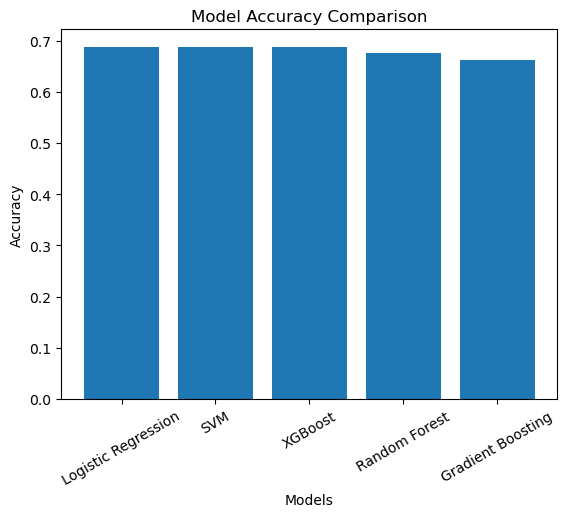

In [9]:
# 8. PLOT: MODEL ACCURACY
# ============================================

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()


In [10]:
# 9. SELECT BEST MODEL
# ============================================

best_model_name = results_df.iloc[0]["Model"]
final_model = best_models[best_model_name]

print(f"\n🔥 Best Model: {best_model_name}")


🔥 Best Model: Logistic Regression


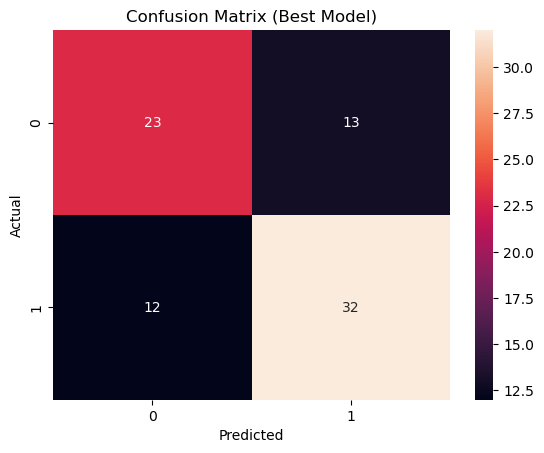

In [11]:
# 10. CONFUSION MATRIX (BEST MODEL)
# ============================================

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
# 13. SAVE MODEL + COLUMNS
# ============================================

joblib.dump(final_model, "heart_model.pkl")
joblib.dump(list(X.columns), "columns.pkl")

print("\n✅ Model and columns saved successfully!")

AttributeError: 'numpy.ndarray' object has no attribute 'columns'